<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Attempt_at_a_Hysteresis_Loop_from_Scratch_with_CuPy_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

## Numerical model used in this computation

The notebook now uses one consistent normalized Stoner-Wohlfarth energy,

$$
E(\theta;h,\phi_H)
=
\frac{1}{2}\sin^2\theta
-
h\cos(\theta-\phi_H),
$$

with $h=H/H_K$.  The equilibrium condition and local stability condition are

$$
\frac{\partial E}{\partial\theta}
=
\sin\theta\cos\theta
+
h\sin(\theta-\phi_H)
=
0,
$$

and

$$
\frac{\partial^2 E}{\partial\theta^2}
=
\cos(2\theta)
+
h\cos(\theta-\phi_H)
>
0.
$$


The field sweep uses numerical continuation.  Each field point starts from the preceding relaxed magnetic state, preserving metastability until the local minimum loses positive curvature.  CuPy evaluates the energy, torque, curvature, damped Newton updates, backtracking, and branch histories on the CUDA GPU.  Host transfer occurs only after both sweeps have completed and Matplotlib needs the finished arrays.

In [1]:
# Google Colab CUDA backend
!uv pip install -q -U cupy-cuda12x

In [2]:
"""Configure the CuPy Stoner-Wohlfarth hysteresis calculation."""

import cupy as cp
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------
# CONTROL KNOBS
# ---------------------------------------------------
GPU_DEVICE = 0

PHI_DEGREES = np.array(
    [0.0, 30.0, 60.0, 90.0],
    dtype=np.float64,
)

H_MIN = -1.5
H_MAX = 1.5
FIELD_POINTS = 2001

MAX_RELAX_ITERS = 128
MAX_BACKTRACK_STEPS = 10

TORQUE_TOL = 1.0e-10
CURVATURE_FLOOR = 1.0e-12
MAX_NEWTON_STEP_RAD = 0.15
INSTABILITY_KICK_RAD = 0.05

# ---------------------------------------------------
# PLOTTING
# ---------------------------------------------------
plt.rcParams["figure.dpi"] = 250
plt.rcParams["figure.figsize"] = (8.0, 6.0)
plt.rcParams["figure.facecolor"] = "#000000"
plt.rcParams["axes.facecolor"] = "#000000"
plt.rcParams["axes.edgecolor"] = "#FFFFFF"
plt.rcParams["axes.labelcolor"] = "#FFFFFF"
plt.rcParams["xtick.color"] = "#FFFFFF"
plt.rcParams["ytick.color"] = "#FFFFFF"
plt.rcParams["text.color"] = "#FFFFFF"
plt.rcParams["font.size"] = 14
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["lines.linewidth"] = 2.0
plt.rcParams["grid.color"] = "#444444"

# ---------------------------------------------------
# GPU CHECK
# ---------------------------------------------------
device_count = cp.cuda.runtime.getDeviceCount()
if device_count < 1:
    raise RuntimeError(
        "No CUDA GPU is visible. Select a GPU runtime in Colab."
    )

cp.cuda.Device(GPU_DEVICE).use()

device_properties = cp.cuda.runtime.getDeviceProperties(GPU_DEVICE)
device_name = device_properties["name"]
if isinstance(device_name, bytes):
    device_name = device_name.decode()

print(f"CuPy version: {cp.__version__}")
print(f"CUDA devices: {device_count}")
print(f"Active GPU: {device_name}")

CuPy version: 14.2.0
CUDA devices: 1
Active GPU: NVIDIA L4


In [3]:
"""Run the hysteresis sweep numerically with CuPy array operations."""


def stoner_wohlfarth_energy(theta, h, phi):
    """Return the normalized Stoner-Wohlfarth energy."""
    return (
        0.5 * cp.sin(theta) ** 2
        - h * cp.cos(theta - phi)
    )


def stoner_wohlfarth_torque(theta, h, phi):
    """Return the angular energy derivative dE/dtheta."""
    return (
        cp.sin(theta) * cp.cos(theta)
        + h * cp.sin(theta - phi)
    )


def stoner_wohlfarth_curvature(theta, h, phi):
    """Return the angular energy curvature d2E/dtheta2."""
    return (
        cp.cos(2.0 * theta)
        + h * cp.cos(theta - phi)
    )


def wrap_angle(theta):
    """Wrap angles to the interval [-pi, pi]."""
    return cp.arctan2(cp.sin(theta), cp.cos(theta))


def relax_local_minimum(theta, h, phi):
    """Relax an angle ensemble to stable local energy minima on the GPU.

    The preceding field point supplies ``theta``, so the calculation follows
    the metastable branch continuously. A damped Newton update is accepted
    only if it lowers the energy. Once positive curvature disappears, an
    overdamped descent step releases the state from the unstable stationary
    point.

    Args:
        theta: CuPy array containing the preceding equilibrium angles.
        h: Scalar reduced field for the current continuation step.
        phi: CuPy array containing applied-field angles.

    Returns:
        Tuple containing relaxed angles, iteration counts, and convergence
        flags for every field angle.
    """
    theta = theta.copy()

    converged = cp.zeros(theta.shape, dtype=cp.bool_)
    iteration_count = cp.full(
        theta.shape,
        MAX_RELAX_ITERS,
        dtype=cp.int32,
    )

    for iteration in range(MAX_RELAX_ITERS):
        torque = stoner_wohlfarth_torque(theta, h, phi)
        curvature = stoner_wohlfarth_curvature(theta, h, phi)

        stable = curvature > CURVATURE_FLOOR
        stationary = cp.abs(torque) <= TORQUE_TOL
        converged_now = stable & stationary

        first_convergence = (~converged) & converged_now
        iteration_count = cp.where(
            first_convergence,
            iteration + 1,
            iteration_count,
        )
        converged |= converged_now

        if bool(cp.all(converged).item()):
            break

        active = ~converged

        # Exact symmetry can leave zero torque at an unstable stationary
        # point. The kick is applied only after positive curvature is lost.
        unstable_stationary = (
            active
            & (curvature <= CURVATURE_FLOOR)
            & stationary
        )
        theta = cp.where(
            unstable_stationary,
            theta + INSTABILITY_KICK_RAD,
            theta,
        )

        # Re-evaluate after the instability release.
        torque = stoner_wohlfarth_torque(theta, h, phi)
        curvature = stoner_wohlfarth_curvature(theta, h, phi)

        newton_mask = active & (curvature > CURVATURE_FLOOR)
        safe_curvature = cp.where(
            newton_mask,
            curvature,
            1.0,
        )

        newton_step = cp.clip(
            torque / safe_curvature,
            -MAX_NEWTON_STEP_RAD,
            MAX_NEWTON_STEP_RAD,
        )

        energy_0 = stoner_wohlfarth_energy(theta, h, phi)

        candidate = theta.copy()
        accepted = ~newton_mask
        scale = cp.ones_like(theta)

        for _ in range(MAX_BACKTRACK_STEPS):
            trial = theta - scale * newton_step
            energy_trial = stoner_wohlfarth_energy(
                trial,
                h,
                phi,
            )

            accept_now = (
                newton_mask
                & (~accepted)
                & (energy_trial <= energy_0 + 1.0e-15)
            )

            candidate = cp.where(
                accept_now,
                trial,
                candidate,
            )
            accepted |= accept_now

            if bool(cp.all(accepted).item()):
                break

            scale = cp.where(
                accepted,
                scale,
                0.5 * scale,
            )

        fallback_newton = newton_mask & (~accepted)
        fallback_newton_step = min(
            MAX_NEWTON_STEP_RAD,
            0.02,
        )

        candidate = cp.where(
            fallback_newton,
            theta
            - cp.sign(torque) * fallback_newton_step,
            candidate,
        )

        nonconvex_mask = active & (~newton_mask)
        descent_step = min(
            MAX_NEWTON_STEP_RAD,
            0.05,
        )

        candidate = cp.where(
            nonconvex_mask,
            theta - cp.sign(torque) * descent_step,
            candidate,
        )

        theta = wrap_angle(candidate)

    torque = stoner_wohlfarth_torque(theta, h, phi)
    curvature = stoner_wohlfarth_curvature(theta, h, phi)

    final_converged = (
        (cp.abs(torque) <= TORQUE_TOL)
        & (curvature > CURVATURE_FLOOR)
    )
    converged |= final_converged

    return theta, iteration_count, converged


def sweep_branch(h_values, phi, initial_theta):
    """Follow one field-history branch with GPU numerical continuation."""
    n_phi = int(phi.size)
    n_h = int(h_values.size)

    theta_history = cp.empty(
        (n_phi, n_h),
        dtype=cp.float64,
    )
    magnetization_history = cp.empty(
        (n_phi, n_h),
        dtype=cp.float64,
    )
    iteration_history = cp.empty(
        (n_phi, n_h),
        dtype=cp.int32,
    )
    convergence_history = cp.empty(
        (n_phi, n_h),
        dtype=cp.bool_,
    )

    theta = initial_theta.copy()

    for field_index in range(n_h):
        h = h_values[field_index]

        theta, iterations, converged = relax_local_minimum(
            theta,
            h,
            phi,
        )

        theta_history[:, field_index] = theta
        magnetization_history[:, field_index] = cp.cos(
            theta - phi
        )
        iteration_history[:, field_index] = iterations
        convergence_history[:, field_index] = converged

    return {
        "theta": theta_history,
        "m": magnetization_history,
        "iterations": iteration_history,
        "converged": convergence_history,
    }


def run_gpu_hysteresis(phi_degrees):
    """Compute forward and backward hysteresis branches using CuPy."""
    phi_host = np.asarray(
        phi_degrees,
        dtype=np.float64,
    )
    phi_gpu = cp.deg2rad(
        cp.asarray(phi_host, dtype=cp.float64)
    )

    h_forward = cp.linspace(
        H_MIN,
        H_MAX,
        FIELD_POINTS,
        dtype=cp.float64,
    )
    h_backward = h_forward[::-1].copy()

    forward = sweep_branch(
        h_forward,
        phi_gpu,
        phi_gpu + cp.pi,
    )
    backward = sweep_branch(
        h_backward,
        phi_gpu,
        phi_gpu,
    )

    torque_forward = cp.abs(
        stoner_wohlfarth_torque(
            forward["theta"],
            h_forward[None, :],
            phi_gpu[:, None],
        )
    )
    torque_backward = cp.abs(
        stoner_wohlfarth_torque(
            backward["theta"],
            h_backward[None, :],
            phi_gpu[:, None],
        )
    )

    all_converged = bool(
        cp.all(forward["converged"]).item()
        and cp.all(backward["converged"]).item()
    )

    all_finite = bool(
        cp.all(cp.isfinite(forward["theta"])).item()
        and cp.all(cp.isfinite(backward["theta"])).item()
        and cp.all(cp.isfinite(forward["m"])).item()
        and cp.all(cp.isfinite(backward["m"])).item()
    )

    max_torque_residual = float(
        cp.maximum(
            cp.max(torque_forward),
            cp.max(torque_backward),
        ).item()
    )

    max_iterations_used = int(
        cp.maximum(
            cp.max(forward["iterations"]),
            cp.max(backward["iterations"]),
        ).item()
    )

    return {
        "phi_degrees": phi_host,
        "phi": phi_gpu,
        "h_forward": h_forward,
        "h_backward": h_backward,
        "forward": forward,
        "backward": backward,
        "diagnostics": {
            "all_converged": all_converged,
            "all_finite": all_finite,
            "max_torque_residual": max_torque_residual,
            "max_iterations_used": max_iterations_used,
        },
    }


results = run_gpu_hysteresis(PHI_DEGREES)

print("CuPy numerical relaxation complete.")
print(
    "All field points converged:",
    results["diagnostics"]["all_converged"],
)
print(
    "All calculated values finite:",
    results["diagnostics"]["all_finite"],
)
print(
    "Maximum |dE/dtheta| residual:",
    f'{results["diagnostics"]["max_torque_residual"]:.3e}',
)
print(
    "Maximum relaxation iterations used:",
    results["diagnostics"]["max_iterations_used"],
)

CuPy numerical relaxation complete.
All field points converged: True
All calculated values finite: True
Maximum |dE/dtheta| residual: 9.977e-11
Maximum relaxation iterations used: 51


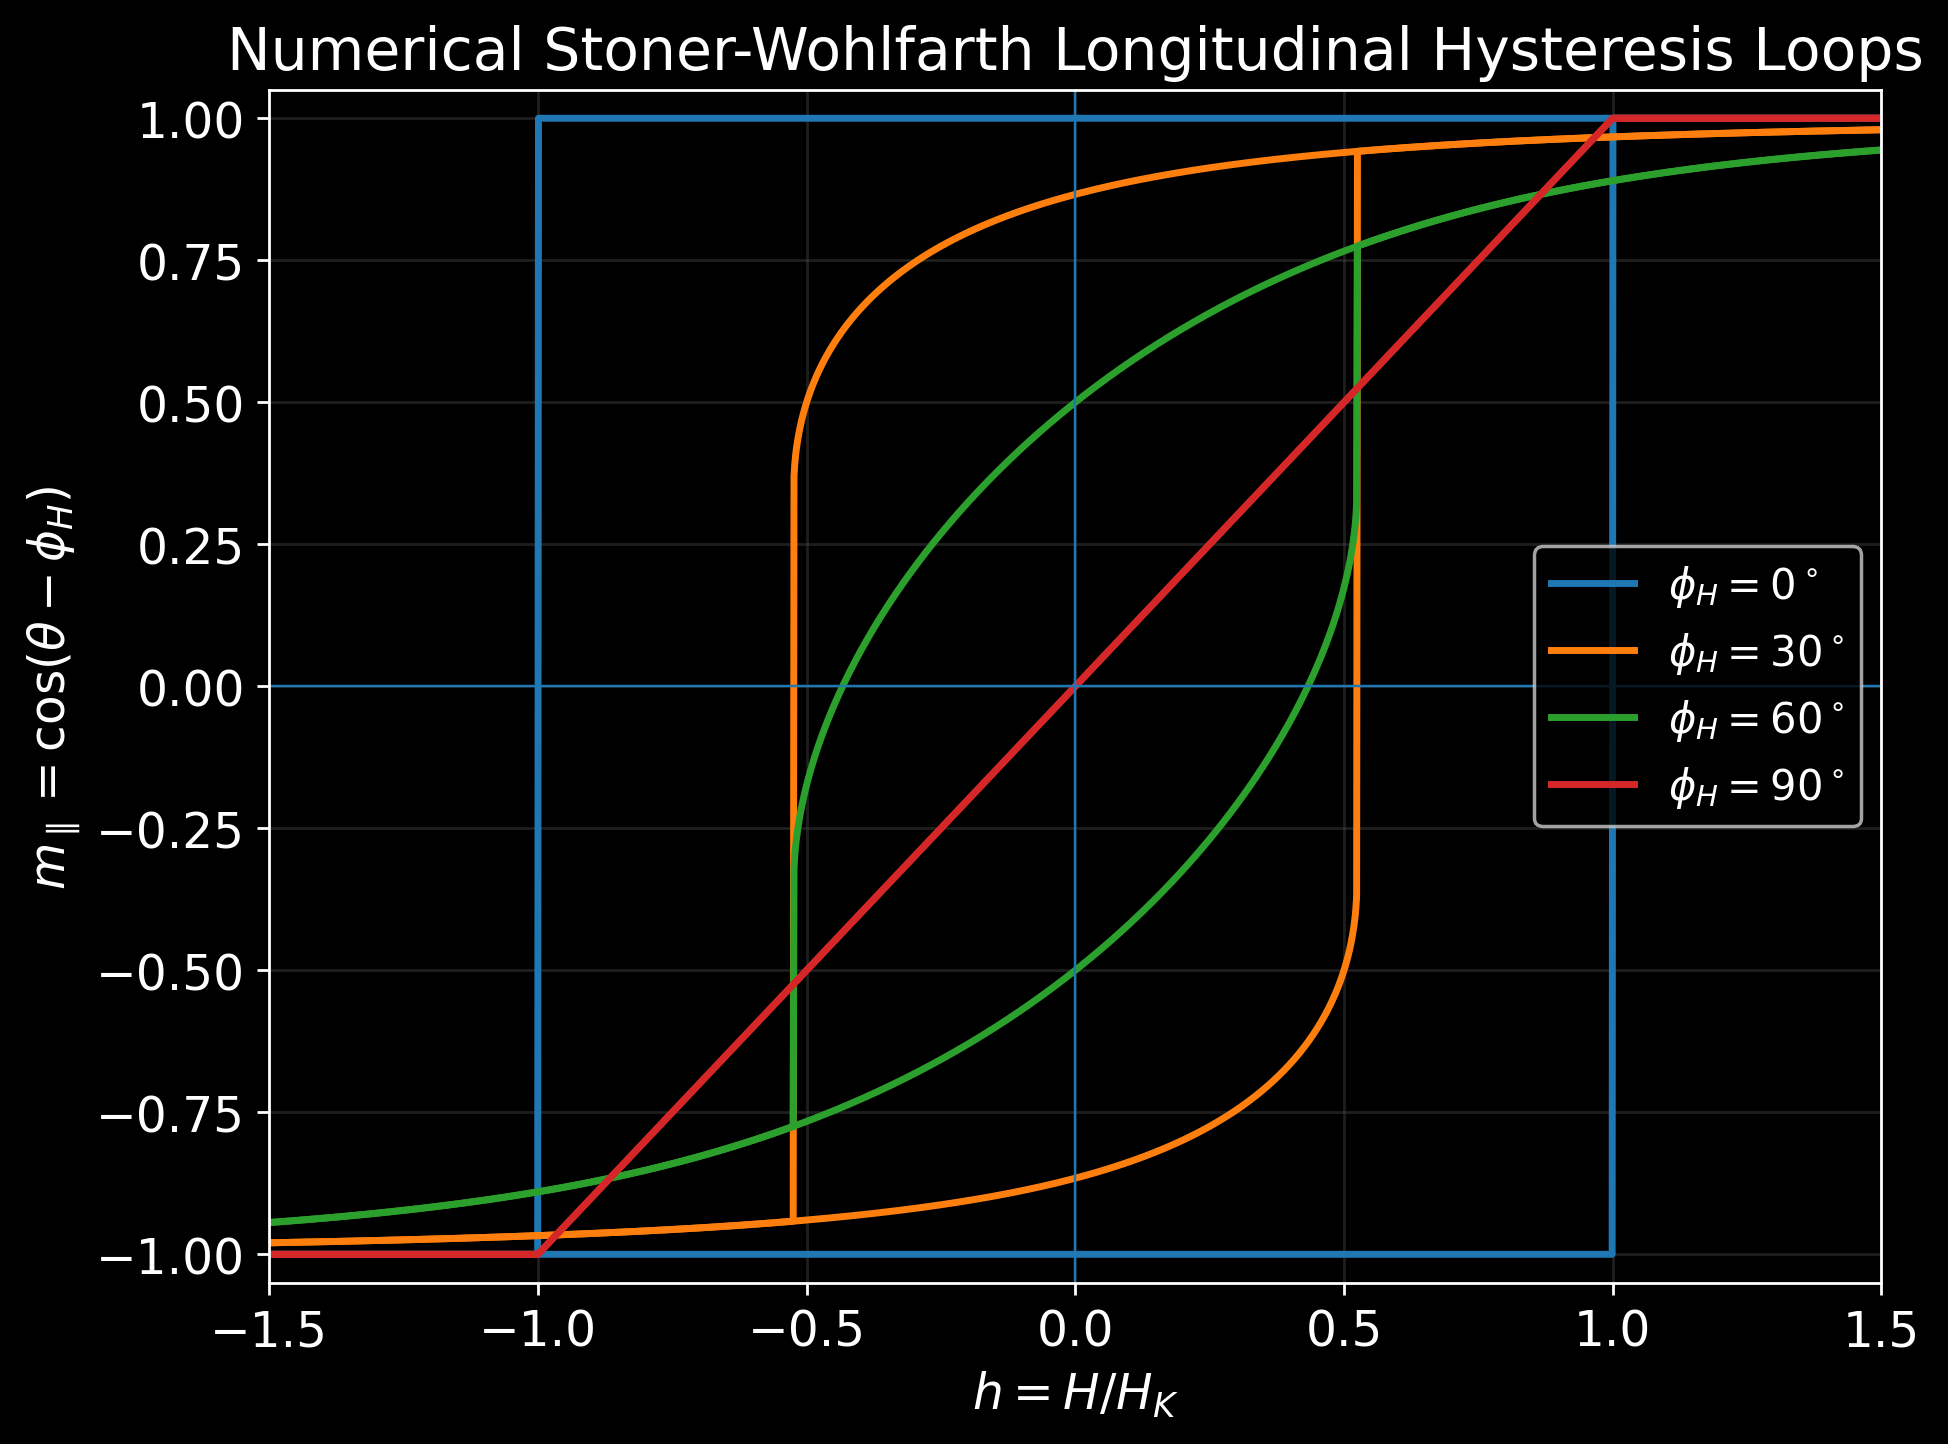

In [4]:
"""Transfer completed curves to the CPU and render the hysteresis loops."""

h_forward_plot = cp.asnumpy(results["h_forward"])
h_backward_plot = cp.asnumpy(results["h_backward"])

m_forward_plot = cp.asnumpy(results["forward"]["m"])
m_backward_plot = cp.asnumpy(results["backward"]["m"])

phi_plot = results["phi_degrees"]

fig, ax = plt.subplots(figsize=(8.0, 6.0))

for index, phi_deg in enumerate(phi_plot):
    forward_line, = ax.plot(
        h_forward_plot,
        m_forward_plot[index],
        label=rf"$\phi_H={phi_deg:g}^\circ$",
    )

    ax.plot(
        h_backward_plot,
        m_backward_plot[index],
        color=forward_line.get_color(),
    )

ax.axhline(0.0, linewidth=0.7)
ax.axvline(0.0, linewidth=0.7)

ax.set_xlabel(r"$h = H/H_K$")
ax.set_ylabel(r"$m_{\parallel} = \cos(\theta-\phi_H)$")
ax.set_title(
    "Numerical Stoner-Wohlfarth Longitudinal Hysteresis Loops"
)

ax.set_xlim(H_MIN, H_MAX)
ax.set_ylim(-1.05, 1.05)
ax.grid(True, alpha=0.45)
ax.legend(loc="best")

plt.tight_layout()
plt.show()